<a href="https://colab.research.google.com/github/rsekola/Projet_data/blob/master/Cluster_d'apprentissage_non_supervis%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("Credit_card_dataset.csv")
print(df.head())
print(df.info())
print(df.describe(include="all"))

  CUST_ID  BALANCE_FREQUENCY  PURCHASES     PAYMENTS  CREDIT_LIMIT  \
0  C10001           0.818182      95.40   201.802084        1000.0   
1  C10002           0.909091       0.00  4103.032597        7000.0   
2  C10003           1.000000     773.17   622.066742        7500.0   
3  C10004           0.636364    1499.00     0.000000        7500.0   
4  C10005           1.000000      16.00   678.334763        1200.0   

   CASH_ADVANCE  
0      0.000000  
1   6442.945483  
2      0.000000  
3    205.788017  
4      0.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("Credit_card_dataset.csv")

print(df.isnull().sum())
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(df.isnull().sum())

if "CUST_ID" in df.columns:
    df = df.drop_duplicates(subset="CUST_ID")

for col in num_cols:
    df = df[df[col] >= 0]

label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

for col in num_cols:
    df = remove_outliers_iqr(df, col)

print("Shape final :", df.shape)
print("Aperçu final :")
print(df.head())


CUST_ID              0
BALANCE_FREQUENCY    0
PURCHASES            0
PAYMENTS             0
CREDIT_LIMIT         1
CASH_ADVANCE         0
dtype: int64
CUST_ID              0
BALANCE_FREQUENCY    0
PURCHASES            0
PAYMENTS             0
CREDIT_LIMIT         0
CASH_ADVANCE         0
dtype: int64
Shape final : (5564, 6)
Aperçu final :
   CUST_ID  BALANCE_FREQUENCY  PURCHASES     PAYMENTS  CREDIT_LIMIT  \
0        0           0.818182      95.40   201.802084        1000.0   
2        2           1.000000     773.17   622.066742        7500.0   
4        4           1.000000      16.00   678.334763        1200.0   
5        5           1.000000    1333.28  1400.057770        1800.0   
7        7           1.000000     436.20   679.065082        2300.0   

   CASH_ADVANCE  
0           0.0  
2           0.0  
4           0.0  
5           0.0  
7           0.0  


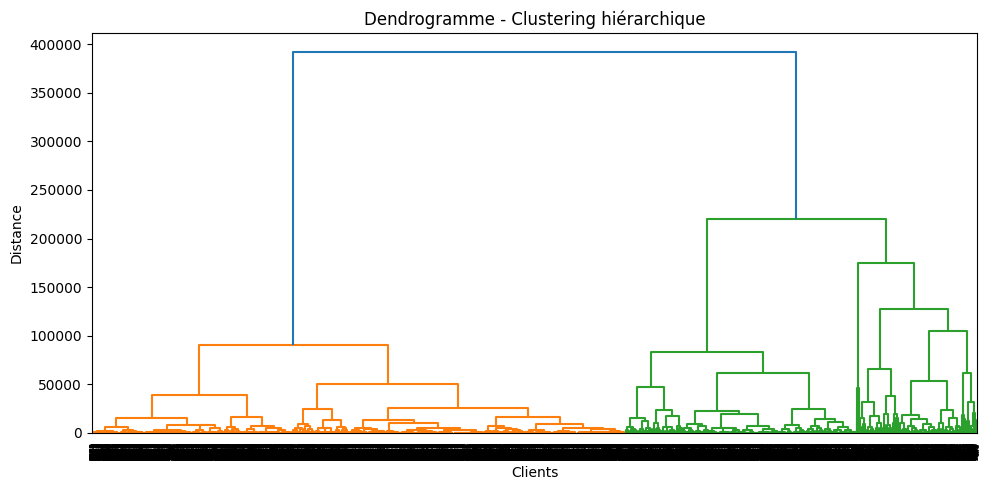

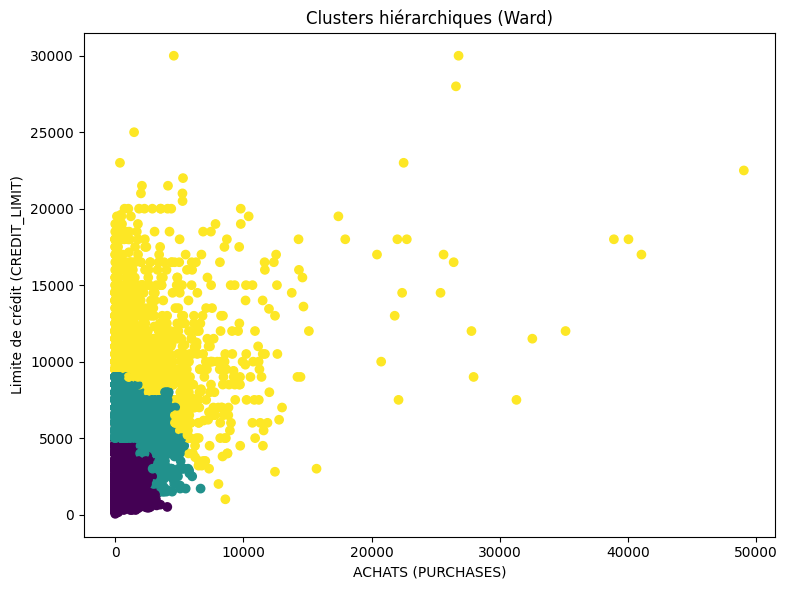

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

df = pd.read_csv('Credit_card_dataset.csv')

data = df[['PURCHASES', 'CREDIT_LIMIT']].dropna()

Z = linkage(data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogramme - Clustering hiérarchique")
plt.xlabel("Clients")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

clusters = fcluster(Z, t=3, criterion='maxclust')

plt.figure(figsize=(8,6))
plt.scatter(data['PURCHASES'], data['CREDIT_LIMIT'], c=clusters)
plt.title("Clusters hiérarchiques (Ward)")
plt.xlabel("ACHATS (PURCHASES)")
plt.ylabel("Limite de crédit (CREDIT_LIMIT)")
plt.tight_layout()
plt.show()


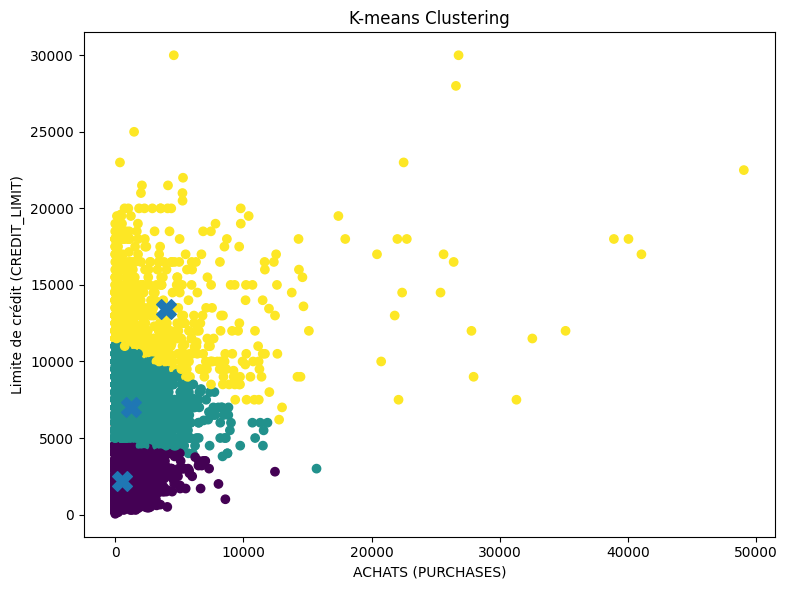

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
df = pd.read_csv('Credit_card_dataset.csv')

data = df[['PURCHASES', 'CREDIT_LIMIT']].dropna()

kmeans = KMeans(n_clusters=3, n_init=10)
clusters = kmeans.fit_predict(data)

plt.figure(figsize=(8, 6))
plt.scatter(data['PURCHASES'], data['CREDIT_LIMIT'], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.title("K-means Clustering")
plt.xlabel("ACHATS (PURCHASES)")
plt.ylabel("Limite de crédit (CREDIT_LIMIT)")
plt.tight_layout()
plt.show()


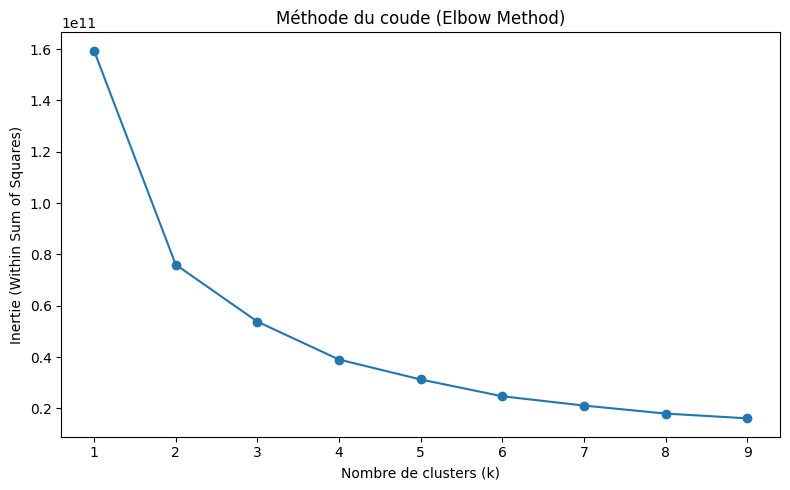

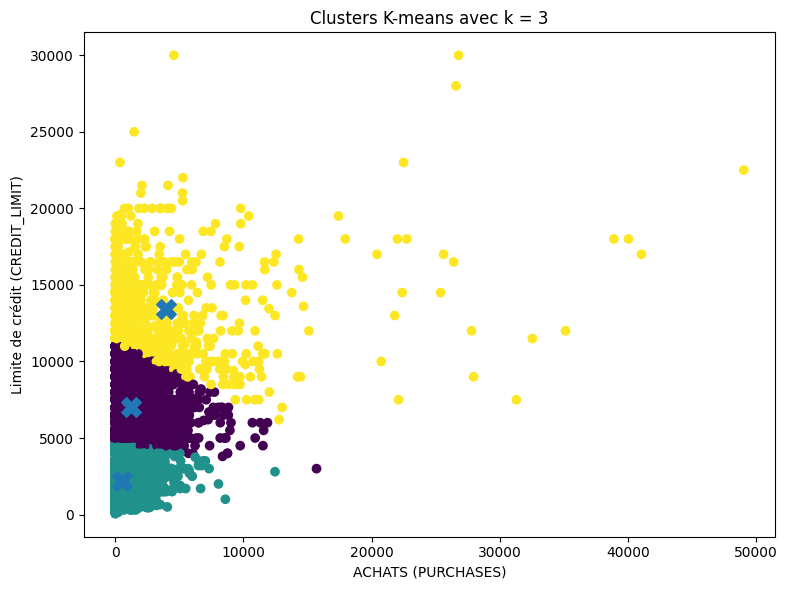

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Credit_card_dataset.csv')

data = df[['PURCHASES', 'CREDIT_LIMIT']].dropna()

inertias = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (Within Sum of Squares)")
plt.title("Méthode du coude (Elbow Method)")
plt.tight_layout()
plt.show()

k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, n_init=10)
clusters = kmeans.fit_predict(data)

plt.figure(figsize=(8,6))
plt.scatter(data['PURCHASES'], data['CREDIT_LIMIT'], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.xlabel("ACHATS (PURCHASES)")
plt.ylabel("Limite de crédit (CREDIT_LIMIT)")
plt.title(f"Clusters K-means avec k = {k_optimal}")
plt.tight_layout()
plt.show()


✔ Le dataset contient 3 types principaux de comportements d’achat

→ cohérent avec les stratégies marketing : basiques, standards, premium.

✔ La variable CREDIT_LIMIT est fortement corrélée au niveau d’achat

→ plus un client dépense, plus sa limite de crédit est élevée.

✔ Le clustering est cohérent et exploitable pour :

segmentation marketing

détection de profils risqués

attribution de limites de crédit

ciblage d’offres ou promotions